<a href="https://colab.research.google.com/github/AdeelAsghar11/deep-learning-playground/blob/main/keras_hp_tuner_sonarmine_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mayurdalvi_sonar_mine_dataset_path = kagglehub.dataset_download('mayurdalvi/sonar-mine-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mayurdalvi/sonar-mine-dataset/sonar data.csv


In [ ]:
df = pd.read_csv("/kaggle/input/datasets/mayurdalvi/sonar-mine-dataset/sonar data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    float64
 21  0.5071  207 non-null    float64
 22  0.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# create encoder
le = LabelEncoder()

# encode column R
df['R'] = le.fit_transform(df['R'])

print(df.head())

   0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109  \
0  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
1  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
2  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
3  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
4  0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105   

   0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084  \
0  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
1  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
2  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
3  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   
4  0.3039  ...  0.0045  0.0014  0.0038  0.0013  0.0089  0.0057  0.0027   

   0.0090  0.0032  R  
0  0.0052  0.0044  1  
1  0.0095  0.0078  1  
2  0.0040  0.0117  1  


In [ ]:
pd.set_option('display.max_rows', None)
df.corr()['R']

0.0200   -0.270482
0.0371   -0.231670
0.0428   -0.192589
0.0207   -0.247935
0.0954   -0.224809
0.0986   -0.132172
0.1539   -0.117848
0.1601   -0.191424
0.3109   -0.329180
0.2111   -0.342199
0.1609   -0.431452
0.1582   -0.390331
0.2238   -0.311948
0.0645   -0.151116
0.0660   -0.051240
0.2273   -0.008246
0.3100    0.006070
0.2999   -0.011635
0.5078   -0.138648
0.4797   -0.223143
0.5783   -0.242818
0.5071   -0.199643
0.4328   -0.123539
0.5550   -0.071733
0.6711   -0.025284
0.6415   -0.026867
0.7104   -0.055324
0.8080   -0.085259
0.6791   -0.037543
0.3857    0.000364
0.1307    0.121008
0.2604    0.059882
0.5121    0.105149
0.7547    0.165523
0.8537    0.220761
0.8507    0.262727
0.6692    0.203826
0.6097    0.034187
0.4943   -0.061572
0.2744    0.037101
0.0510   -0.013833
0.2834   -0.144705
0.2825   -0.236109
0.4256   -0.284527
0.2641   -0.342801
0.1386   -0.305624
0.1051   -0.301527
0.1343   -0.334199
0.0383   -0.350441
0.0324   -0.185623
0.0232   -0.297358
0.0027   -0.284528
0.0065   -0.

In [ ]:
X = df.drop("R", axis=1)
Y = df["R"]

In [ ]:
X

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0104,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062
5,0.0317,0.0956,0.1321,0.1408,0.1674,0.1710,0.0731,0.1401,0.2083,0.3513,...,0.0195,0.0201,0.0248,0.0131,0.0070,0.0138,0.0092,0.0143,0.0036,0.0103
6,0.0519,0.0548,0.0842,0.0319,0.1158,0.0922,0.1027,0.0613,0.1465,0.2838,...,0.0052,0.0081,0.0120,0.0045,0.0121,0.0097,0.0085,0.0047,0.0048,0.0053
7,0.0223,0.0375,0.0484,0.0475,0.0647,0.0591,0.0753,0.0098,0.0684,0.1487,...,0.0061,0.0145,0.0128,0.0145,0.0058,0.0049,0.0065,0.0093,0.0059,0.0022
8,0.0164,0.0173,0.0347,0.0070,0.0187,0.0671,0.1056,0.0697,0.0962,0.0251,...,0.0118,0.0090,0.0223,0.0179,0.0084,0.0068,0.0032,0.0035,0.0056,0.0040
9,0.0039,0.0063,0.0152,0.0336,0.0310,0.0284,0.0396,0.0272,0.0323,0.0452,...,0.0062,0.0062,0.0120,0.0052,0.0056,0.0093,0.0042,0.0003,0.0053,0.0036


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(64, activation="relu",input_dim=60))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="Adam", loss="binary_crossentropy", metrics= ["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train,y_train, batch_size=32, epochs = 100, validation_data= (X_test,y_test))

Epoch 1/100


I0000 00:00:1772757899.830312     128 service.cc:152] XLA service 0x79d1b00039d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772757899.830346     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772757899.830350     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772757900.078565     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/6 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5938 - loss: 0.6876

I0000 00:00:1772757900.661865     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.5772 - loss: 0.6835 - val_accuracy: 0.5952 - val_loss: 0.6485
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5398 - loss: 0.6730 - val_accuracy: 0.5952 - val_loss: 0.6406
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5760 - loss: 0.6537 - val_accuracy: 0.6190 - val_loss: 0.6338
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6006 - loss: 0.6399 - val_accuracy: 0.6190 - val_loss: 0.6291
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6582 - loss: 0.6398 - val_accuracy: 0.6667 - val_loss: 0.6246
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6519 - loss: 0.6292 - val_accuracy: 0.6667 - val_loss: 0.6200
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6405 - loss: 0.6201 - val_accuracy: 0.6667 - val_loss: 0.6159
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6810 - loss: 0.6039 - val_accuracy: 0.6667 - val_loss: 0.6130
Epo

In [ ]:
import keras_tuner as kt

In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(64, activation="relu",input_dim=60))

    model.add(Dense(1, activation="sigmoid"))
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd', 'adagrad'])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics= ["accuracy"])

    return model

In [ ]:
tuner = kt.RandomSearch(build_model, objective="val_accuracy", max_trials =10)

Reloading Tuner from ./untitled_project/tuner0.json


In [ ]:
tuner.search(X_train, y_train, epochs = 10, validation_data = (X_test,y_test))

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print(best_hp.values)

{'optimizer': 'rmsprop'}


In [ ]:
model = tuner.get_best_models(num_models = 1)[0]

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, batch_size = 32, epochs = 100, initial_epoch =6, validation_data = (X_test, y_test))

Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9141 - loss: 0.2862 - val_accuracy: 0.7619 - val_loss: 0.5445
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8867 - loss: 0.3170 - val_accuracy: 0.7857 - val_loss: 0.5675
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8847 - loss: 0.3421 - val_accuracy: 0.6905 - val_loss: 0.5213
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9141 - loss: 0.2953 - val_accuracy: 0.7381 - val_loss: 0.5360
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9029 - loss: 0.3166 - val_accuracy: 0.7381 - val_loss: 0.5307
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9355 - loss: 0.2815 - val_accuracy: 0.7143 - val_loss: 0.5139
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9112 - loss: 0.3062 - val_accuracy: 0.7143 - val_loss: 0.5155
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8982 - loss: 0.3158 - val_accuracy: 0.7857 - val

In [ ]:
def build_model(hp):
    model = Sequential()

    units = hp.Int("neurons", 16, 256, step=16)

    model.add(Dense(units=units, activation="relu", input_shape=(60,)))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(build_model, objective="val_accuracy", max_trials=10, directory= "my")

In [ ]:
tuner.search(X_train, y_train, epochs = 10, validation_data=(X_test, y_test))

Trial 10 Complete [00h 00m 03s]
val_accuracy: 0.7142857313156128

Best val_accuracy So Far: 0.8095238208770752
Total elapsed time: 00h 00m 37s


In [ ]:
model = tuner.get_best_model[0]

In [ ]:
tuner.results_summary()

Results summary
Results in my/untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 03 summary
Hyperparameters:
neurons: 128
Score: 0.8095238208770752

Trial 04 summary
Hyperparameters:
neurons: 96
Score: 0.8095238208770752

Trial 07 summary
Hyperparameters:
neurons: 144
Score: 0.761904776096344

Trial 02 summary
Hyperparameters:
neurons: 224
Score: 0.738095223903656

Trial 06 summary
Hyperparameters:
neurons: 48
Score: 0.738095223903656

Trial 01 summary
Hyperparameters:
neurons: 80
Score: 0.7142857313156128

Trial 09 summary
Hyperparameters:
neurons: 64
Score: 0.7142857313156128

Trial 00 summary
Hyperparameters:
neurons: 32
Score: 0.6904761791229248

Trial 05 summary
Hyperparameters:
neurons: 208
Score: 0.6904761791229248

Trial 08 summary
Hyperparameters:
neurons: 192
Score: 0.6904761791229248


In [ ]:
best_model = tuner.hypermodel.build(best_hp)

best_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - accuracy: 0.6543 - loss: 0.6669 - val_accuracy: 0.6905 - val_loss: 0.6562
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6468 - loss: 0.6526 - val_accuracy: 0.6905 - val_loss: 0.6531
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6411 - loss: 0.6509 - val_accuracy: 0.6667 - val_loss: 0.6484
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6296 - loss: 0.6419 - val_accuracy: 0.6667 - val_loss: 0.6461
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6725 - loss: 0.6300 - val_accuracy: 0.7143 - val_loss: 0.6449
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7089 - loss: 0.6419 - val_accuracy: 0.6905 - val_loss: 0.6444
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7163 - loss: 0.6286 - val_accuracy: 0.7143 - val_loss: 0.6387
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7067 - loss: 0.6284 - val_accuracy: 0.6667 - val_loss: 0.6397
Epoch 9/50

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
import keras_tuner as kt

def build_model(hp):

    model = Sequential()

    # number of hidden layers
    for i in range(hp.Int("num_layers", 1, 3)):

        model.add(Dense(
            units = hp.Int(f"units_{i}", 32, 256, step=32),
            activation = "relu"
        ))

        model.add(Dropout(
            hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)
        ))

    model.add(Dense(1, activation="sigmoid"))

    learning_rate = hp.Choice(
        "learning_rate",
        [1e-2, 1e-3, 1e-4]
    )

    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss = "binary_crossentropy",
        metrics = ["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=2,
    directory="tuner_dir",
    project_name="sonar_ann"
)

In [ ]:
tuner.search(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Trial 20 Complete [00h 00m 17s]
val_accuracy: 0.738095223903656

Best val_accuracy So Far: 0.7976190447807312
Total elapsed time: 00h 04m 51s


In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best layers:", best_hp.get("num_layers"))

for i in range(best_hp.get("num_layers")):
    print("Layer", i+1, "neurons:", best_hp.get(f"units_{i}"))
    print("Layer", i+1, "dropout:", best_hp.get(f"dropout_{i}"))

print("Best learning rate:", best_hp.get("learning_rate"))

Best layers: 2
Layer 1 neurons: 96
Layer 1 dropout: 0.2
Layer 2 neurons: 192
Layer 2 dropout: 0.1
Best learning rate: 0.01


In [ ]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]

best_model = tuner.hypermodel.build(best_hp)

In [ ]:
history = best_model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 368ms/step - accuracy: 0.5307 - loss: 0.7360 - val_accuracy: 0.5714 - val_loss: 0.6563
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5401 - loss: 0.6841 - val_accuracy: 0.7143 - val_loss: 0.6276
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7238 - loss: 0.5950 - val_accuracy: 0.6905 - val_loss: 0.5612
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7488 - loss: 0.5249 - val_accuracy: 0.6190 - val_loss: 0.5503
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7803 - loss: 0.4867 - val_accuracy: 0.7619 - val_loss: 0.4982
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7037 - loss: 0.5127 - val_accuracy: 0.7619 - val_loss: 0.4942
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8719 - loss: 0.3992 - val_accuracy: 0.7619 - val_loss: 0.5083
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8122 - loss: 0.3840 - val_accuracy: 0.5952 - val_loss

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset

# Last column is label
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Encode labels (R/M → 0/1)
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
import keras_tuner as kt

def build_model(hp):
    model = Sequential()

    # Tune number of hidden layers (1-3)
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(Dense(
            units=hp.Int(f"units_{i}", 32, 256, step=32),
            activation="relu"
        ))
        model.add(Dropout(
            hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)
        ))

    model.add(Dense(1, activation="sigmoid"))

    learning_rate = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=2,  # reduces variance
    directory="tuner_dir",
    project_name="sonar_ann"
)

Reloading Tuner from tuner_dir/sonar_ann/tuner0.json


In [ ]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
tuner.search(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
print("Number of hidden layers:", best_hp.get("num_layers"))
for i in range(best_hp.get("num_layers")):
    print(f"Layer {i+1} neurons:", best_hp.get(f"units_{i}"))
    print(f"Layer {i+1} dropout:", best_hp.get(f"dropout_{i}"))

print("Learning rate:", best_hp.get("learning_rate"))

# Best validation accuracy
best_model = tuner.hypermodel.build(best_hp)
val_loss, val_acc = best_model.evaluate(X_test, y_test)
print("Best val_accuracy:", val_acc)

Best hyperparameters:
Number of hidden layers: 2
Layer 1 neurons: 96
Layer 1 dropout: 0.30000000000000004
Layer 2 neurons: 192
Layer 2 dropout: 0.1
Learning rate: 0.001
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.3735 - loss: 0.7621
Best val_accuracy: 0.3571428656578064


In [ ]:
history = best_model.fit(
    X_train,
    y_train,
    epochs=100,                  # max epochs; early stopping will likely stop earlier
    validation_data=(X_test, y_test),
    callbacks=[early_stop],      # we already defined early stopping
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 255ms/step - accuracy: 0.5795 - loss: 0.6769 - val_accuracy: 0.6429 - val_loss: 0.6397
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7497 - loss: 0.5645 - val_accuracy: 0.6905 - val_loss: 0.5597
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7694 - loss: 0.5080 - val_accuracy: 0.7619 - val_loss: 0.5092
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7825 - loss: 0.4634 - val_accuracy: 0.8333 - val_loss: 0.4813
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8234 - loss: 0.4025 - val_accuracy: 0.8095 - val_loss: 0.4631
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8482 - loss: 0.3843 - val_accuracy: 0.8095 - val_loss: 0.4496
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8966 - loss: 0.3222 - val_accuracy: 0.7857 - val_loss: 0.4378
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8829 - loss: 0.3115 - val_accuracy: 0.8095 - val_loss

In [ ]:
val_loss, val_acc = best_model.evaluate(X_test, y_test, verbose=0)
print("Final val_accuracy:", val_acc)

Final val_accuracy: 0.8095238208770752


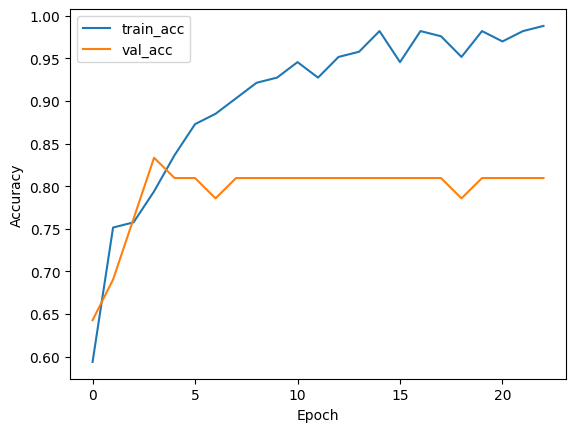

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()